<a href="https://colab.research.google.com/github/swirita/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales

Siwar Ehwass

## Overview


 - The company's objective was to **accurately predict item outlet sales** to support inventory planning and business decision-making.

 - Three models were evaluated: **Linear Regression**, **Default Random Forest**, and **Tuned Random Forest**.

 - **Linear Regression** provided a strong baseline with good generalization (**R² = 0.56**).

 - The **Default Random Forest** suffered from overfitting, performing well on the training data but worse on the test data (**R² = 0.55**).

 - After hyperparameter tuning, the **Random Forest** achieved the best performance (**R² = 0.60**) with improved generalization and lower prediction errors.

 - Overall, the **Tuned Random Forest** best met the company's objective by providing the most accurate and reliable sales predictions for unseen data.


## Data Dictionary

| **Variable Name** | **Description** |
|-------------------|-----------------|
| **Item_Identifier** | Unique identifier for each product. |
| **Item_Weight** | Weight of the product. |
| **Item_Fat_Content** | Indicates whether the product is **Low Fat** or **Regular**. |
| **Item_Visibility** | Percentage of the store's display area allocated to the product. |
| **Item_Type** | Category to which the product belongs. |
| **Item_MRP** | Maximum Retail Price (MRP) of the product. |
| **Outlet_Identifier** | Unique identifier for each store. |
| **Outlet_Establishment_Year** | Year in which the store was established. |
| **Outlet_Size** | Size of the outlet (Small, Medium, or High). |
| **Outlet_Location_Type** | Location tier of the outlet (Tier 1, Tier 2, or Tier 3). |
| **Outlet_Type** | Type of outlet (e.g., Grocery Store or Supermarket). |
| **Item_Outlet_Sales** | Sales of the product in a specific outlet. **This is the target variable to be predicted.** |

## Load and Inspect Data

### Imports

In [11]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config

set_config(transform_output='pandas')

### Loading Data

In [2]:
path='https://docs.google.com/spreadsheets/d/e/2PACX-1vR6AvAZumX2EE8diEPYfNdktYpa8cELog1Iv_SL7EIFj_DIVxnGwq5liujvJ1GTQry9NDkFsISbeWaE/pub?output=csv'
df=pd.read_csv(path)
# check information about the dataset
df.info()
# check first five rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


> What we can interpret from this:
>  1) We have 8523 rows, and 12 columns.
>  2) `Item_Identifier` & `Outlet_Identifier` are merely identifiers, they do not help with model training.
>  3) There is null values in `Item_Weight` & `Outlet_Size`.
>  4) `Outlet_Size`, `Outlet_Location_Type` are Ordinal Features.

## Data Cleaning & Feature Inspection

In [3]:
# Drop ID
df= df.drop(columns=['Item_Identifier','Outlet_Identifier'])

In [4]:
# check for duplicated data
df.duplicated().sum()

np.int64(0)

- there are no duplicated values


In [5]:
# check for unique percentage
df.nunique() / len(df) * 100

,0
Item_Weight,4.869178
Item_Fat_Content,0.058665
Item_Visibility,92.455708
Item_Type,0.187727
Item_MRP,69.670304
Outlet_Establishment_Year,0.105597
Outlet_Size,0.035199
Outlet_Location_Type,0.035199
Outlet_Type,0.046932
Item_Outlet_Sales,40.983222


> **Notes:**
> - It is noticeable that `Item_Visibility` and `Item_MRP` have really high
> variance, however we are not going to drop them as they are useful for training
> the model later.
>
>
> - As expected for the other features, the variation is fairly well and there is no high cardinality features.

In [6]:
# filter out both num and object features
num_cols=df.select_dtypes('number').columns # select numbers
cat_cols=df.select_dtypes('object').columns # select objects

# loop through each one's value counts (objects)
for col in cat_cols:
    print(f'Value counts of {col}:\n {df[col].value_counts(dropna=False)} \n')

Value counts of Item_Fat_Content:
 Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64 

Value counts of Item_Type:
 Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64 

Value counts of Outlet_Size:
 Outlet_Size
Medium    2793
NaN       2410
Small     2388
High       932
Name: count, dtype: int64 

Value counts of Outlet_Location_Type:
 Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64 

Value counts of Outlet_Type:
 O

> What we can get from this:
> 1) For `Item_Fat_Content` feature:
>   - Typos and Inconsistent values (LF, Low Fat, low fat)
> 2) For `Outlet_Size` Feature:
>   - It has 2410 null values.
>   - It is an Ordinal Feature (Small, Medium, High).
> 3) For `Outlet_Location_Type` Feature:
>   - It is an Ordinal Feature (Tier 1, Tier 2, Tier 3).`


In [7]:
# check describe for numbers (loop)
for col in num_cols:
    print(f'Describe for {col}\n {df[col].describe()}')

Describe for Item_Weight
 count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Item_Weight, dtype: float64
Describe for Item_Visibility
 count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64
Describe for Item_MRP
 count    8523.000000
mean      140.992782
std        62.275067
min        31.290000
25%        93.826500
50%       143.012800
75%       185.643700
max       266.888400
Name: Item_MRP, dtype: float64
Describe for Outlet_Establishment_Year
 count    8523.000000
mean     1997.831867
std         8.371760
min      1985.000000
25%      1987.000000
50%      1999.000000
75%      2004.000000
max      2009.000000
Name: Outlet_Establishment_Year, dtype: float64
Describe for Item_Outlet_Sales
 count     8523.000000
mean

> There is no unrealistic value in any feature.
> However, in `Item_Visibility` Some items have visiility of zero, which is unrealistic, going to impute it with a null value.

In [8]:
# Handling Item_Fat_Content

# fix inconsistent values
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({'LF': 'Low Fat',
                                       'low fat': 'Low Fat',
                                       'reg' : 'Regular'})

# Handling Item_Visibility

# Impute all values thats equal to zero with np.nan
df.loc[df['Item_Visibility']==0, 'Item_Visibility'] = np.nan

In [9]:
# check value counts again for fat content
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


### Missing Values


 The Features with null values are:
 - `Item_Visibility`, 526 null value (impute with mean or median)
 - `Item_Weight`, 1463 null values (impute with mean or median)
 - `Outlet_Size`, 2410 missing values, impute with constant 'MISSING' or Most frequent.


In [10]:
# see columns and rows where NaN is present in df
df.isna().sum()

,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,526
Item_Type,0
Item_MRP,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0
Outlet_Type,0
Item_Outlet_Sales,0


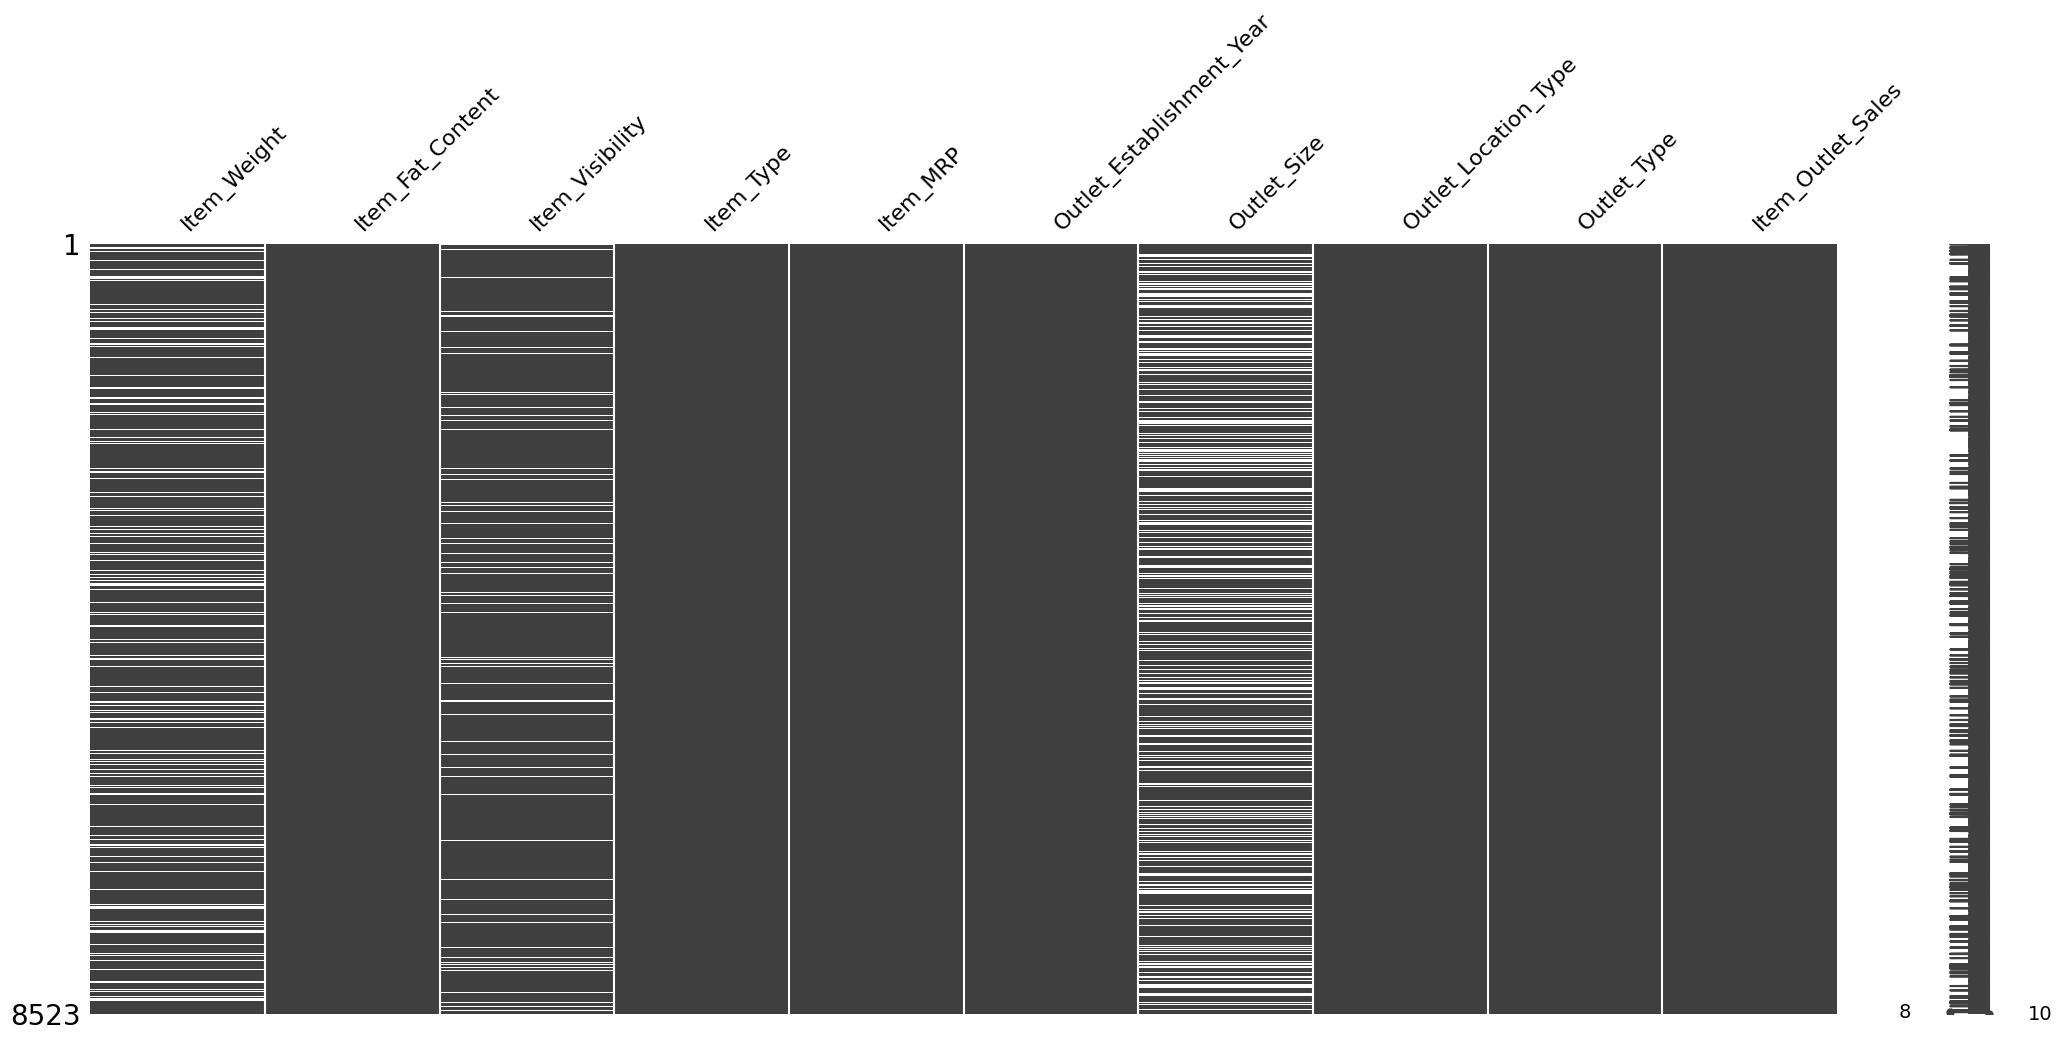

In [12]:
msno.matrix(df);

> ### Missing Values
>
>The missing value matrix shows that:
>- `Item_Weight` contains missing values.
>- `Item_Visibility` contains some missing values.
>- `Outlet_Size` has the highest number of missing values.
>- The remaining features are complete.
>
>Numeric features will be imputed with the **median**, while the categorical feature (`Outlet_Size`) will be imputed with the **most frequent** value (or a constant `"MISSING"` if appropriate).

#### Inspecting Categorical Features

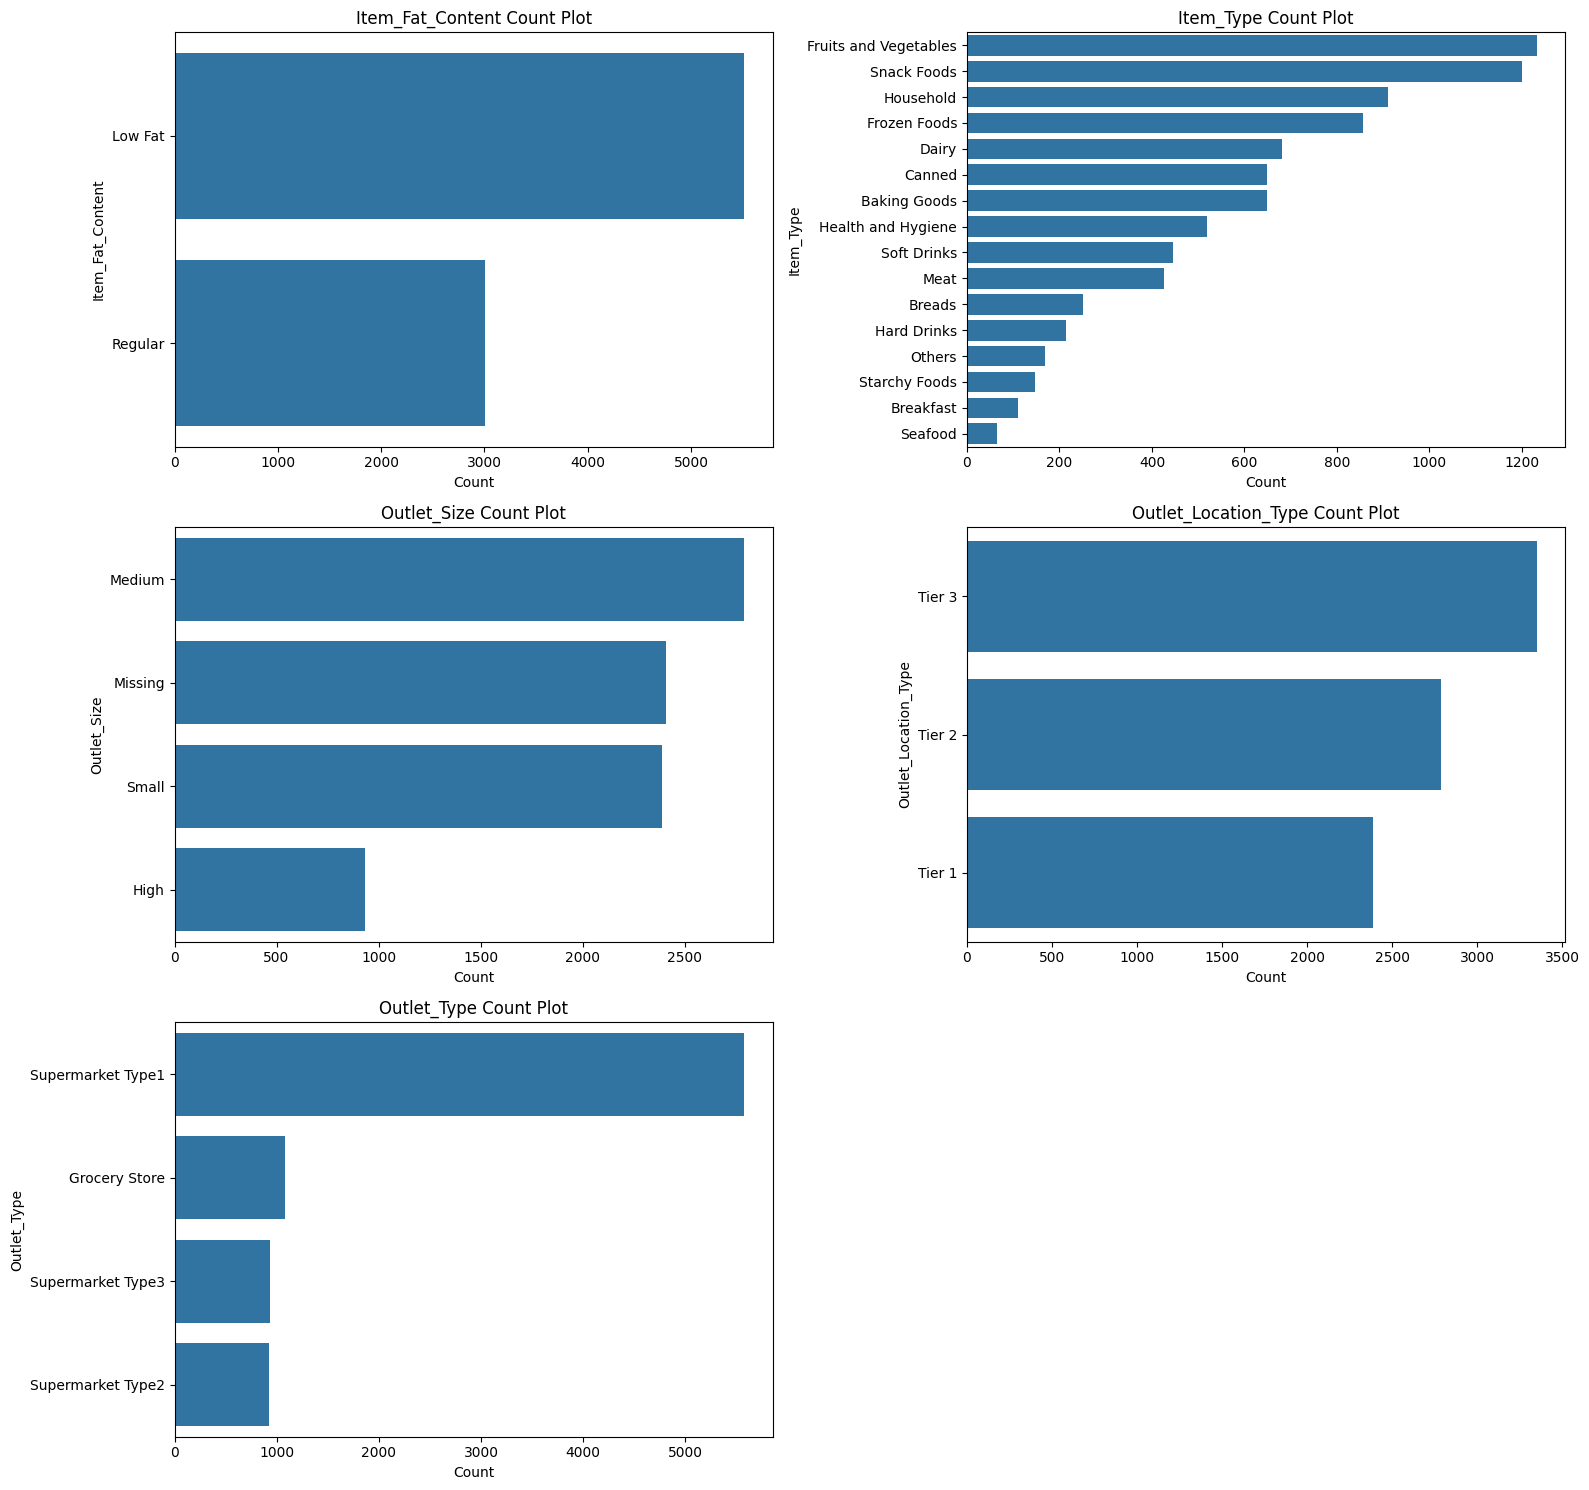

In [15]:
cat_cols = df.select_dtypes(include='object')

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    # Temporary copy for visualization only
    temp = df[col].fillna("Missing")

    sns.countplot(
        y=temp,
        ax=axes[i],
        order=temp.value_counts().index
    )

    axes[i].set_title(f"{col} Count Plot")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(col)

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

>### Categorical Features
>
> `Item_Fat_Content` is dominated by **Low Fat** products.
>
> `Item_Type` is fairly balanced, with **Fruits and Vegetables** being the most common.
>
> `Outlet_Size` has many missing values, so imputing with the **most frequent value (Medium)** is appropriate.
>
> `Tier 3` is the most common outlet location.
>
> `Supermarket Type1` is the dominant outlet type.

#### Inspecting Numeric Columns

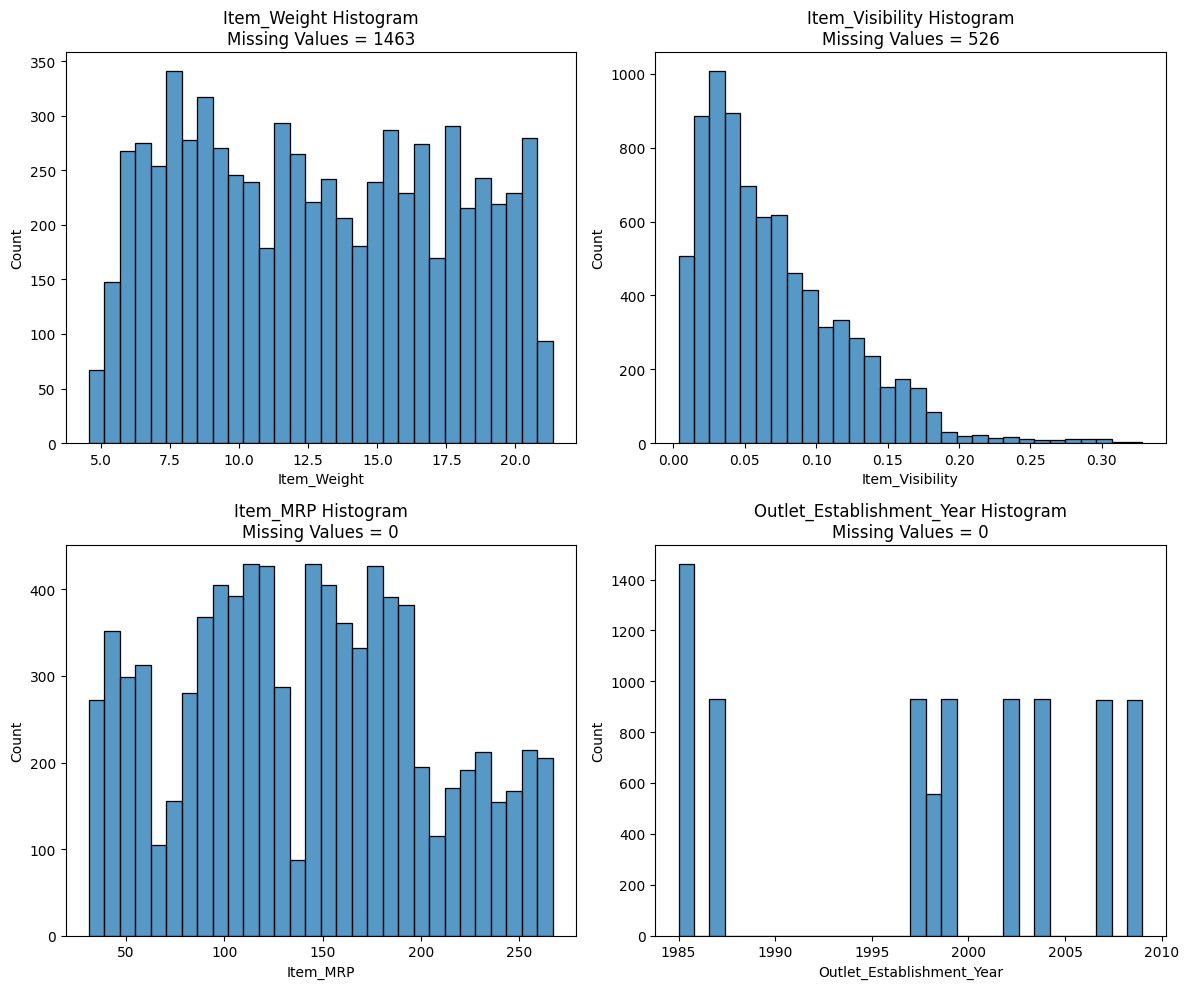

In [16]:
# Select numerical columns (exclude target)
num_cols = df.select_dtypes(include='number').columns.drop('Item_Outlet_Sales')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    missing = df[col].isna().sum()

    sns.histplot(data=df, x=col, bins=30, ax=axes[i])

    axes[i].set_title(f"{col} Histogram\nMissing Values = {missing}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

> ### Numerical Features
>
> `Item_Weight` contains many missing values and is fairly evenly distributed, making **median imputation** appropriate.
>
> `Item_Visibility` is right-skewed, so **median imputation** is preferred if missing values are present.
>
> `Item_MRP` has multiple price groups but no missing values, so no imputation is needed.
>
> `Outlet_Establishment_Year` has no missing values, so no imputation is needed.

## Exploratory Data Analysis

In [20]:
## Exploratory Data Analysis

target = 'Item_Outlet_Sales'

categorical_cols = [
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Type'
]

ordinal_cols = [
    'Outlet_Size',
    'Outlet_Location_Type'
]

numerical_cols = [
    'Item_Weight',
    'Item_Visibility',
    'Item_MRP',
    'Outlet_Establishment_Year'
]

category_orders = {
    'Outlet_Size': ['Small', 'Medium', 'High'],
    'Outlet_Location_Type': ['Tier 1', 'Tier 2', 'Tier 3']
}

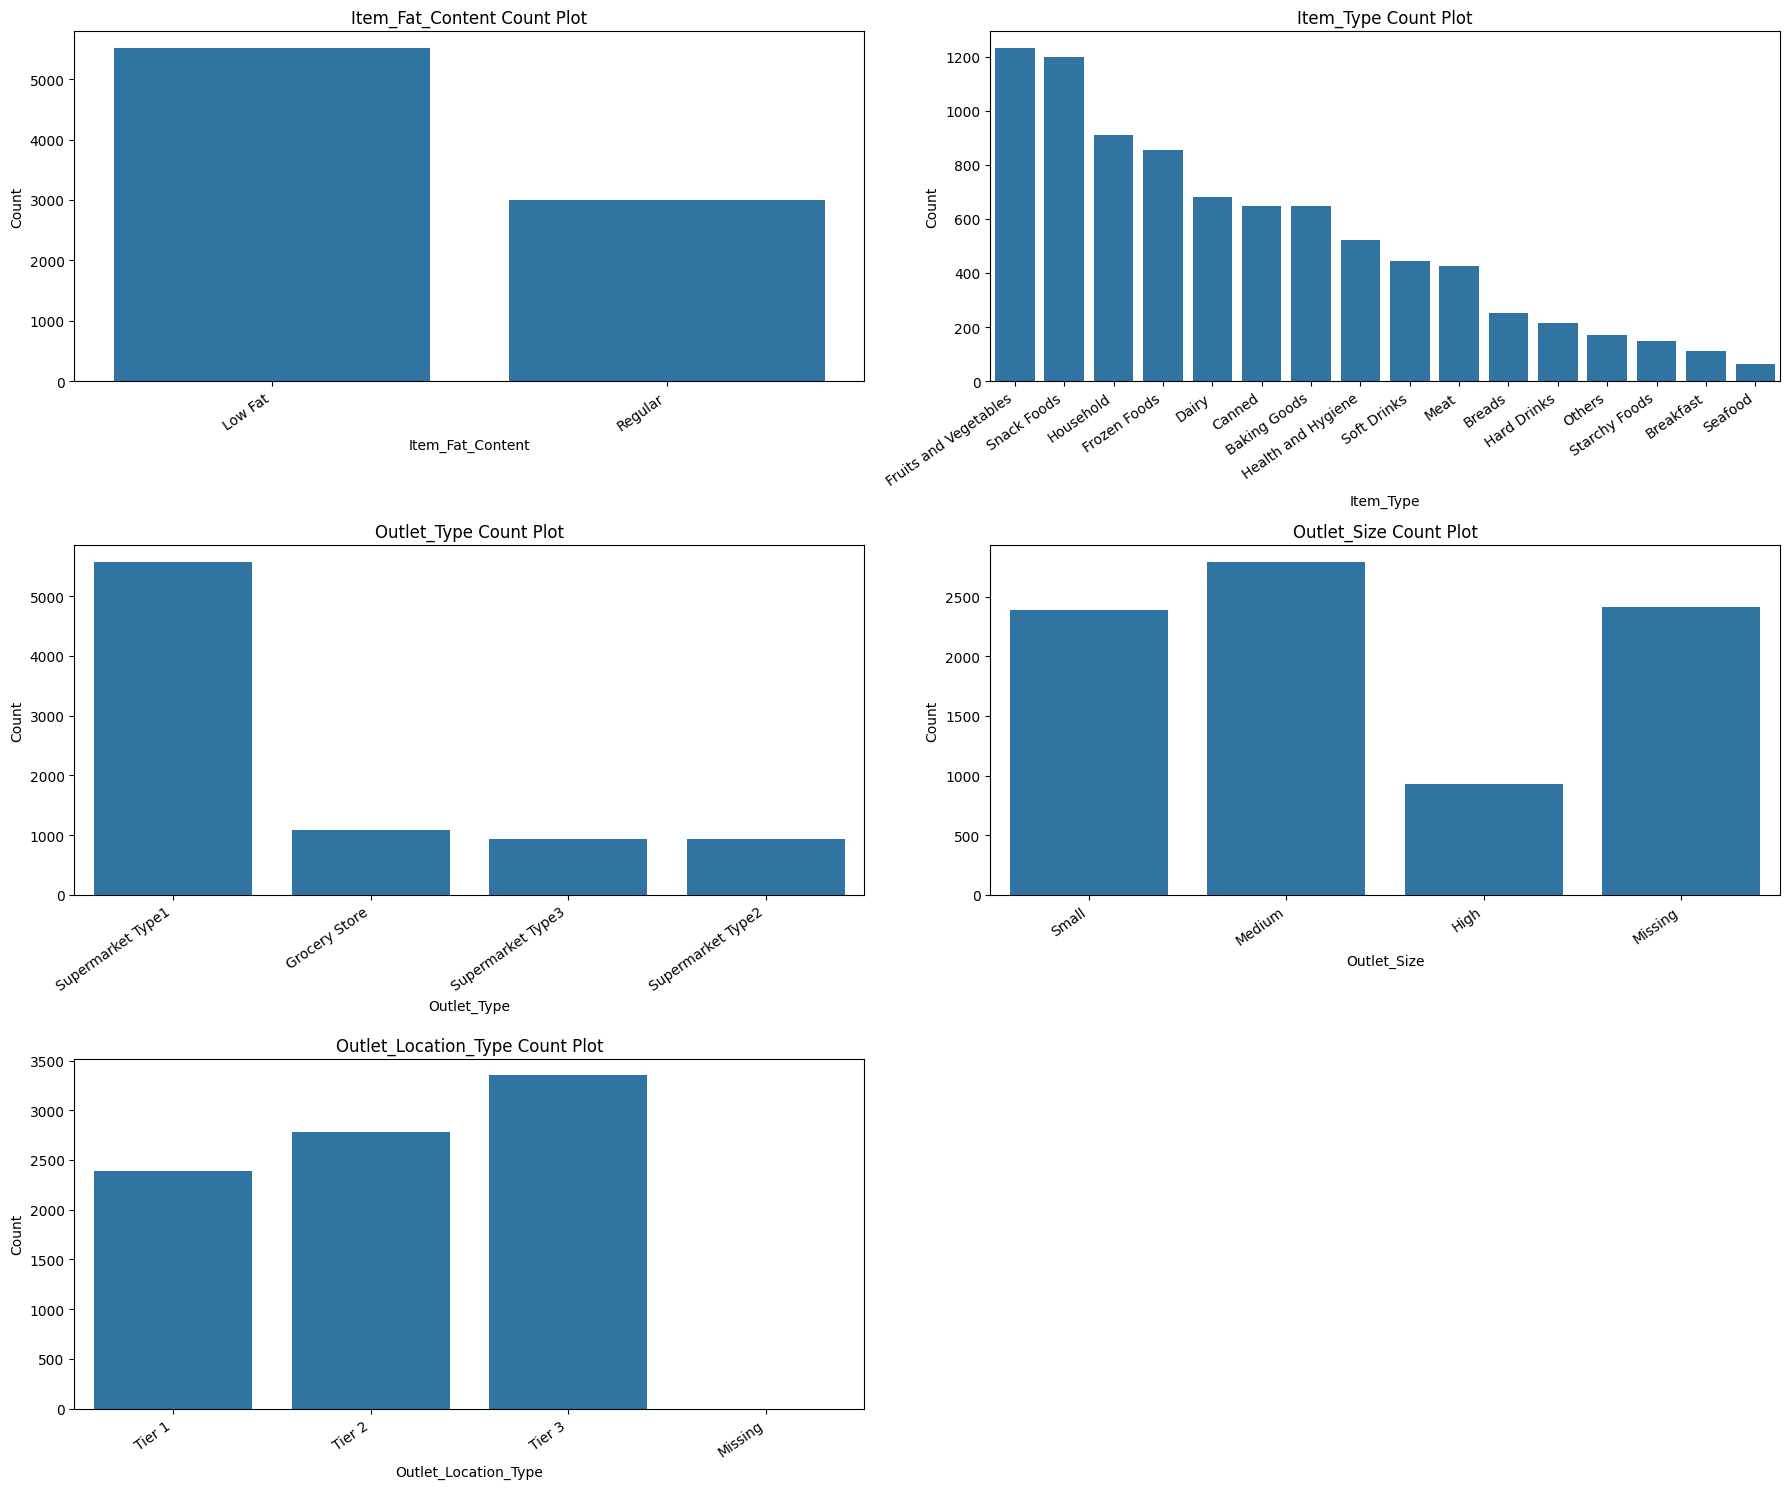

In [21]:
features = categorical_cols + ordinal_cols

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(features):

    temp = df[col].fillna('Missing')

    order = category_orders.get(col)

    if order is None:
        order = temp.value_counts().index
    else:
        order = order + ['Missing']

    sns.countplot(
        x=temp,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} Count Plot')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    axes[i].tick_params(axis='x', rotation=35)

    # Align rotated category names to the right
    for label in axes[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Remove unused subplot
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

> `Item_Fat_Content` is dominated by **Low Fat** products.
>
> `Fruits and Vegetables` and `Snack Foods` are the most common item types.
>
> `Outlet_Size` contains many missing values; imputing with the **most frequent value (Medium)** is appropriate.
>
> `Tier 3` is the most common outlet location.
>
> `Supermarket Type1` is the dominant outlet type.

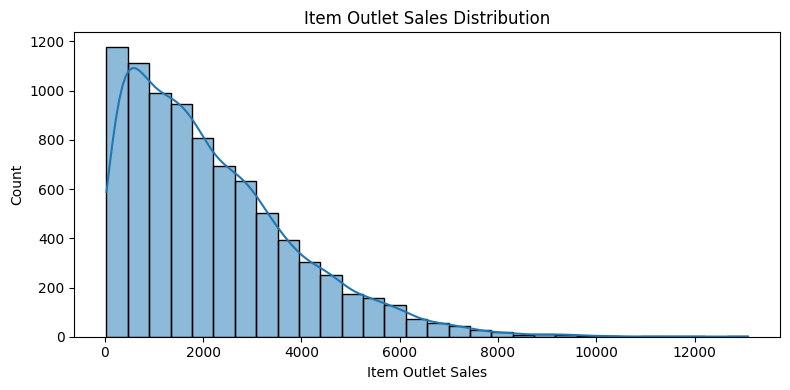

In [22]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x=target,
    bins=30,
    kde=True
)

plt.title('Item Outlet Sales Distribution')
plt.xlabel('Item Outlet Sales')
plt.tight_layout()
plt.show()

> `Item_Outlet_Sales` is right-skewed, with most items having low to moderate sales and a few very high sales values.

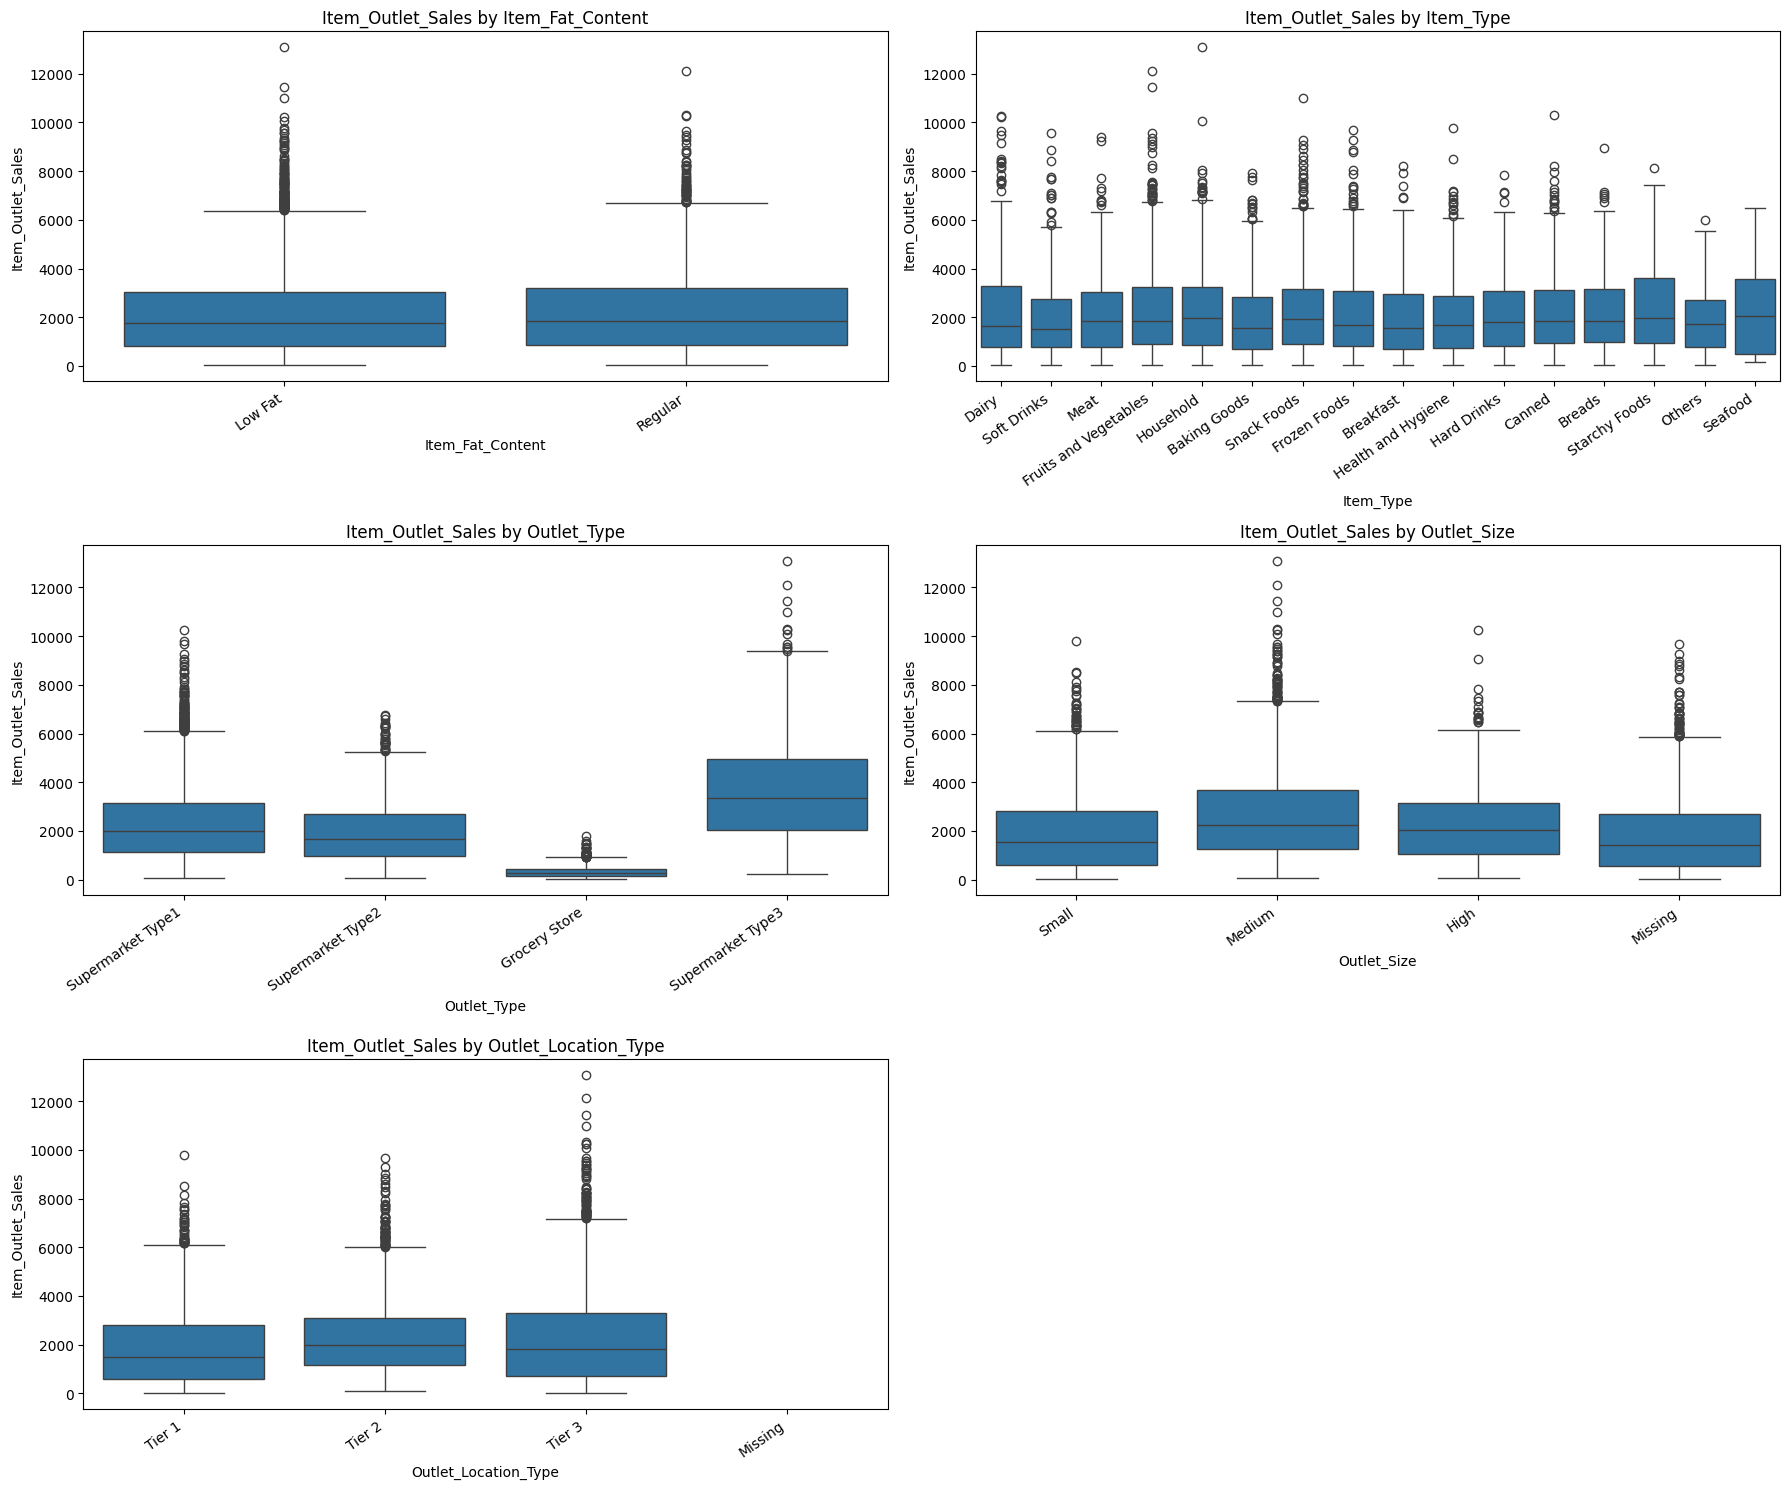

In [23]:
features = categorical_cols + ordinal_cols

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(features):

    temp_df = df.copy()
    temp_df[col] = temp_df[col].fillna('Missing')

    order = category_orders.get(col)

    if order is not None:
        order = order + ['Missing']

    sns.boxplot(
        data=temp_df,
        x=col,
        y=target,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f'{target} by {col}')
    axes[i].tick_params(axis='x', rotation=35)

    for label in axes[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Remove unused subplot
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

> `Outlet_Type` shows the strongest relationship with sales, with **Supermarket Type3** having the highest median sales and **Grocery Store** the lowest.
>
> `Outlet_Size` and `Outlet_Location_Type` also influence sales.
>
> `Item_Fat_Content` and `Item_Type` show only small differences in sales.

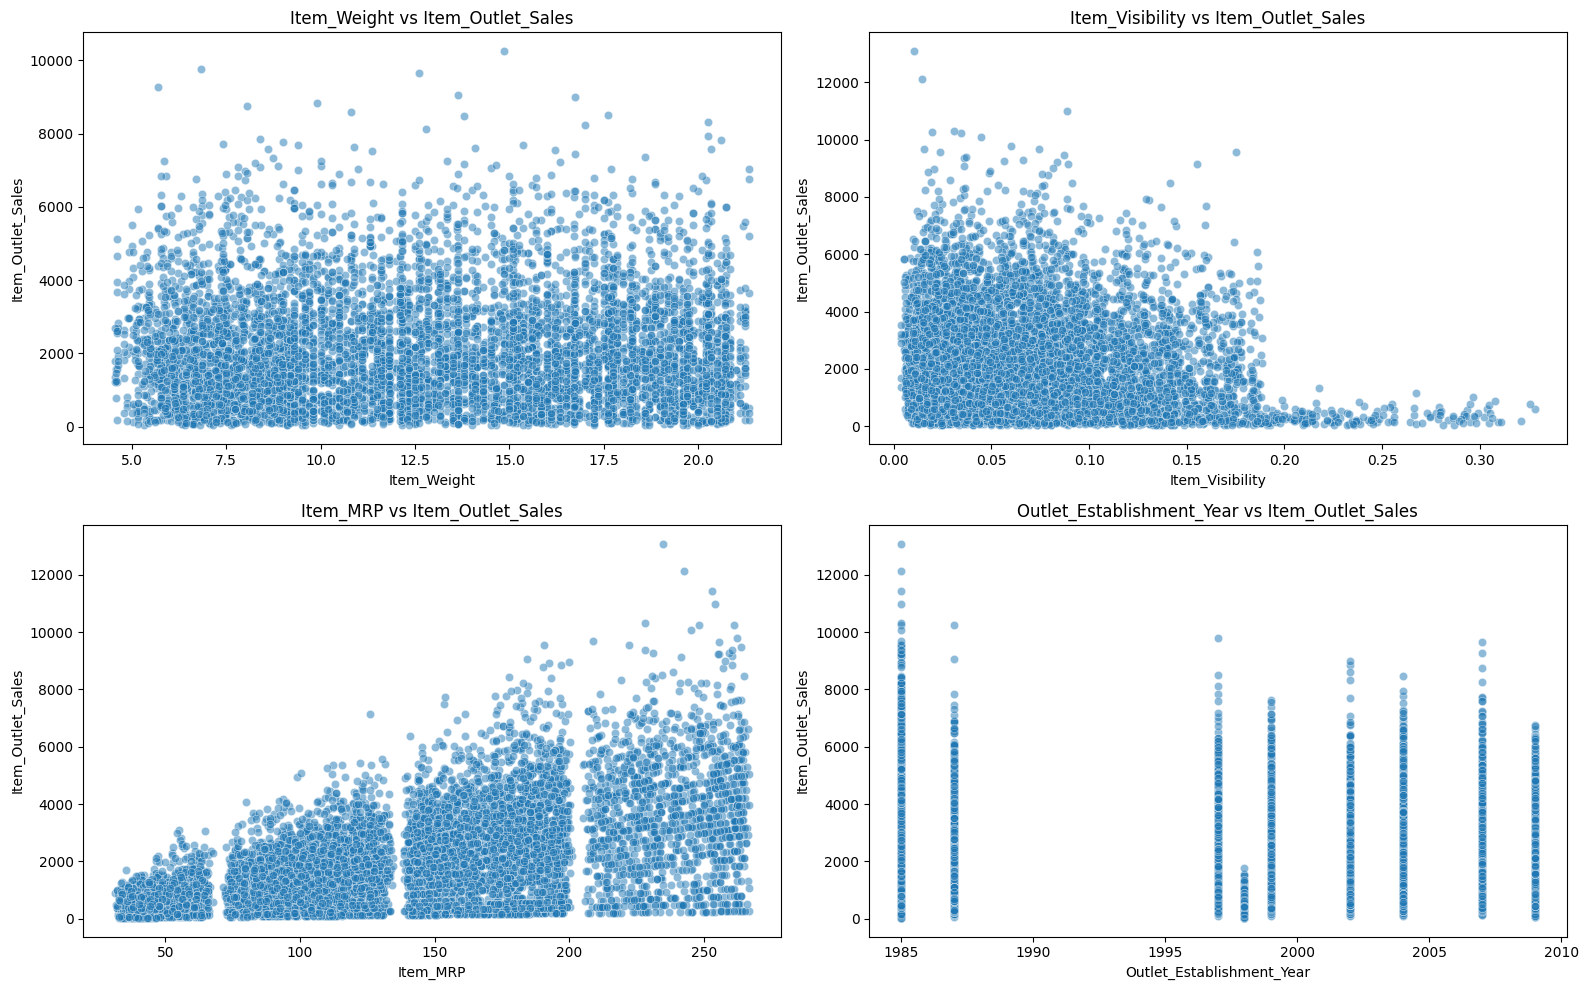

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    subset = df[[col, target]].dropna()

    sns.scatterplot(
        data=subset,
        x=col,
        y=target,
        alpha=0.5,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs {target}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

> `Item_MRP` has the strongest positive relationship with sales.
>
> `Item_Weight` and `Outlet_Establishment_Year` show little relationship with sales.
>
> `Item_Visibility` has a weak negative relationship with sales.

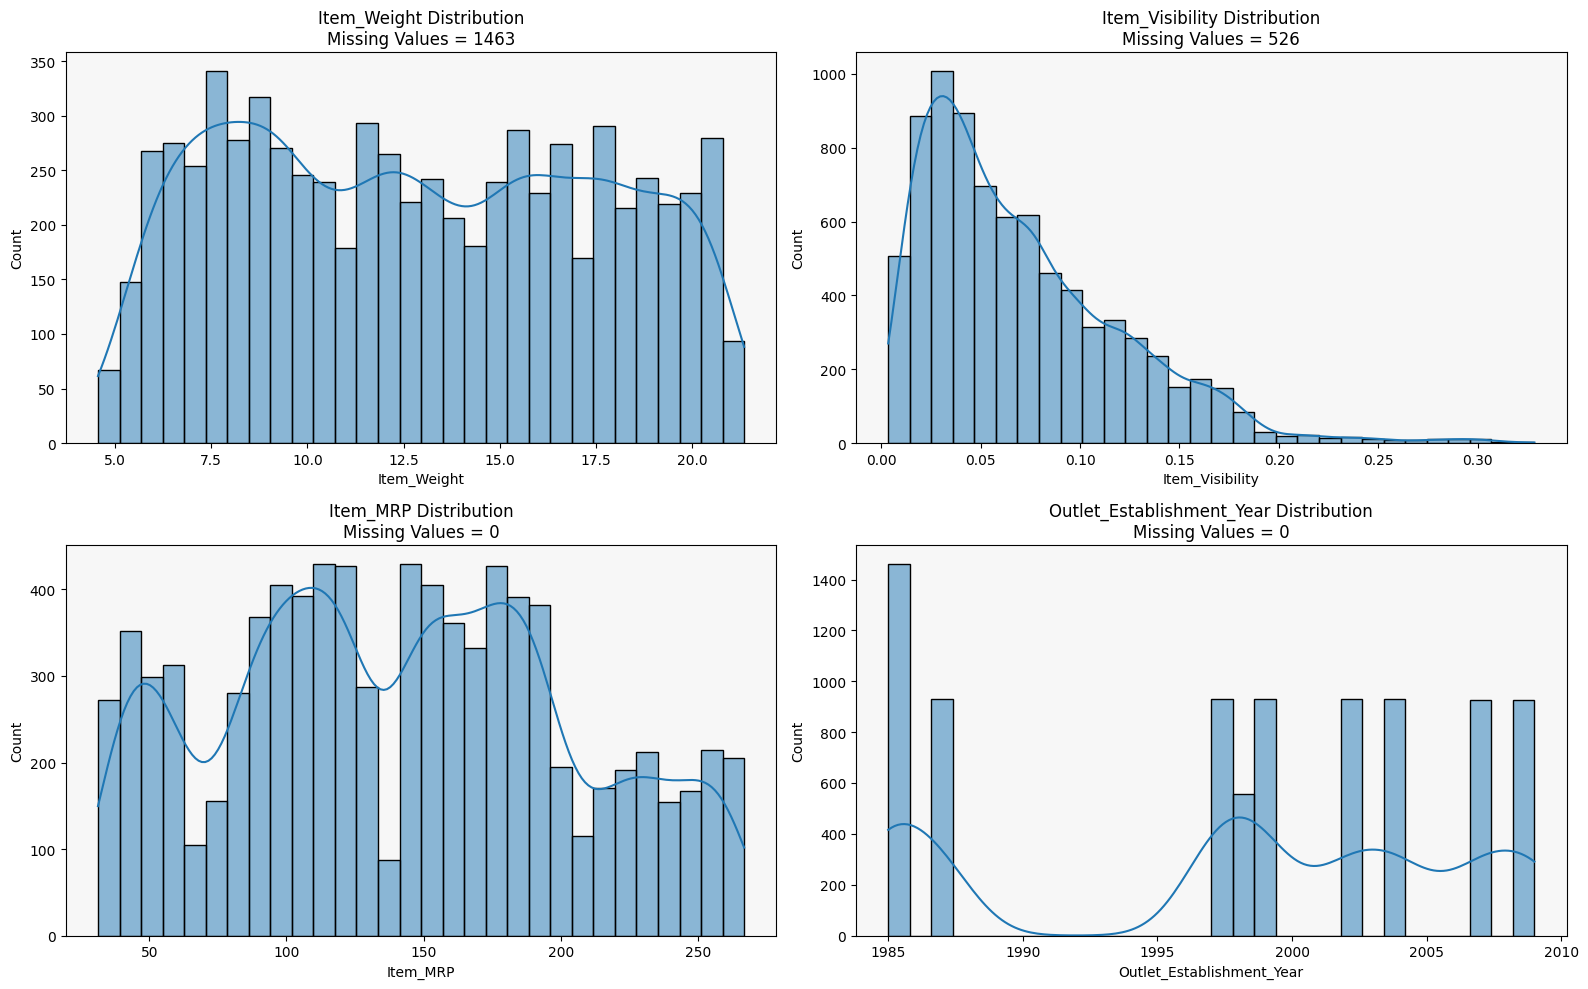

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):

    missing = df[feature].isna().sum()

    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f'{feature} Distribution\nMissing Values = {missing}'
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].set_facecolor('#f7f7f7')

plt.tight_layout()
plt.show()

> `Item_Weight` contains many missing values and should be imputed using the **median**.
>
> `Item_Visibility` is right-skewed and is best imputed using the **median** if missing values are present.
>
> `Item_MRP` has multiple price groups and contains no missing values.
>
> `Outlet_Establishment_Year` contains only specific establishment years and has no missing values.

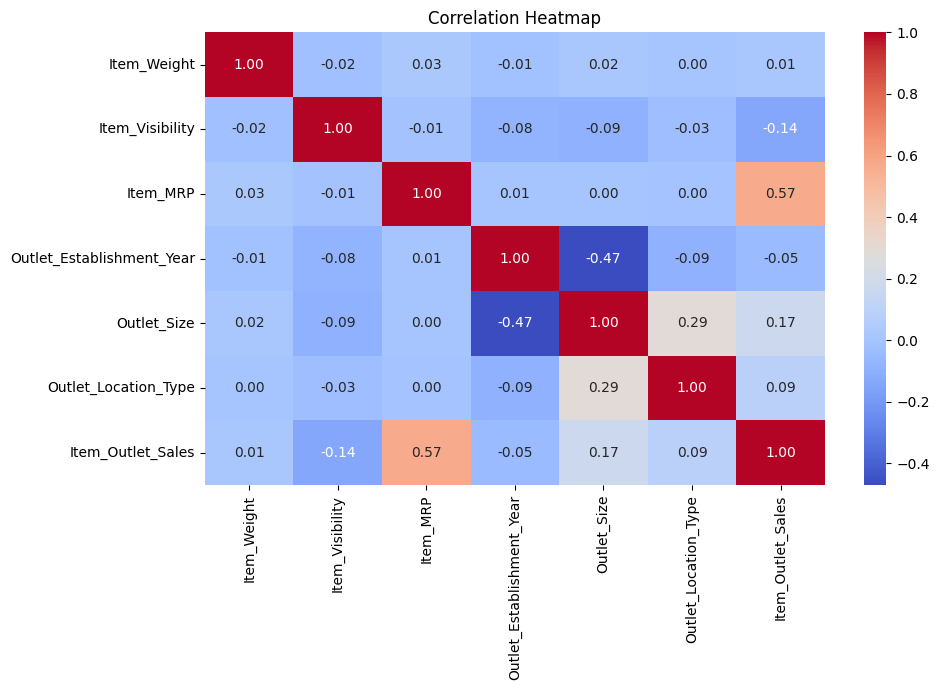

In [27]:
df_corr = df.copy()

ord_cols = [
    'Outlet_Size',
    'Outlet_Location_Type'
]

# Keep missing values as a separate ordinal category
df_corr[ord_cols] = df_corr[ord_cols].fillna('Missing')

encoder = OrdinalEncoder(
    categories=[
        ['Missing', 'Small', 'Medium', 'High'],
        ['Tier 1', 'Tier 2', 'Tier 3']
    ]
)

df_corr[ord_cols] = encoder.fit_transform(df_corr[ord_cols])

# Drop nominal categorical and identifier columns
df_corr = df_corr.drop(
    columns=[
        'Item_Fat_Content',
        'Item_Type',
        'Outlet_Type'
    ]
)

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

> `Item_MRP` has the strongest positive correlation with `Item_Outlet_Sales` (0.57).
>
> `Item_Visibility` has a weak negative correlation with sales (-0.14).
>
> No severe multicollinearity is present among the features.

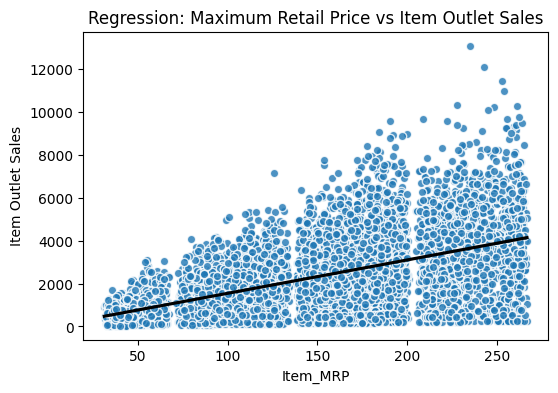

In [28]:
plt.figure(figsize=(6,4))
line_kws = dict(color='black')
scatter_kws = dict(edgecolor='white')

ax = sns.regplot(
    data=df,
    x='Item_MRP',
    y='Item_Outlet_Sales',
    line_kws=line_kws,
    scatter_kws=scatter_kws
)

ax.set(
    xlabel="Item_MRP",
    ylabel="Item Outlet Sales",
    title="Regression: Maximum Retail Price vs Item Outlet Sales"
);

> - There is a positive relationship between Maximum Retail Price and Item Outlet Sales. As retail price increases, sales tend to increase as well.

### OutletType vs Sales

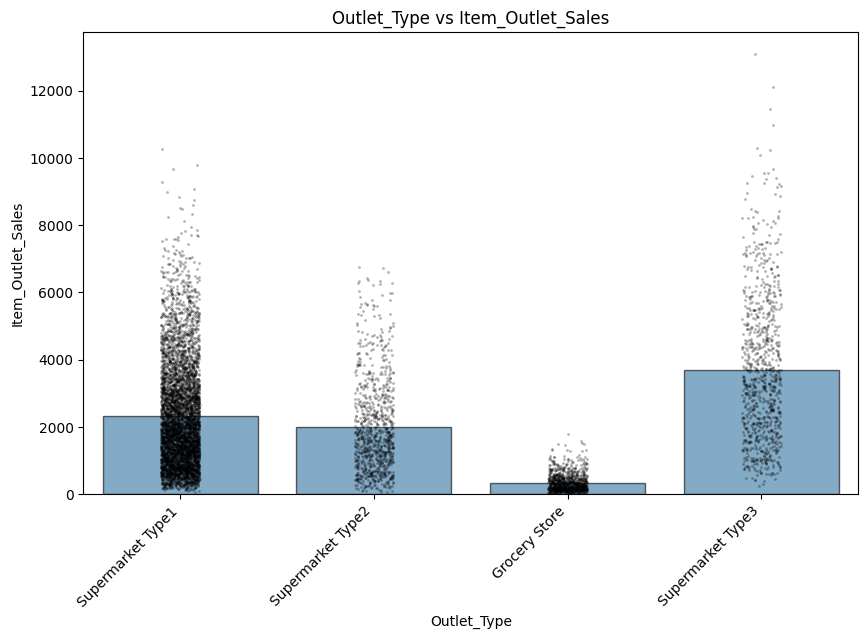

In [ ]:

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Outlet_Type",
    y="Item_Outlet_Sales",
    errorbar=None,
    alpha=0.6,
    edgecolor="black"
)

sns.stripplot(
    data=df,
    x="Outlet_Type",
    y="Item_Outlet_Sales",
    color="black",
    alpha=0.3,
    size=2,
    jitter=True
)

plt.title("Outlet_Type vs Item_Outlet_Sales")
plt.xticks(rotation=45, ha="right");

> **Outlet Type vs Item Outlet Sales Analysis**
>
> - **Supermarket Type3** records the highest sales overall, with the largest median sales and the highest maximum values.
>
> - **Supermarket Type1** also achieves relatively high sales but with greater variability across products.
>
> - **Supermarket Type2** has moderate sales, generally lower than Supermarket Type1 and Type3.
>
> - **Grocery Stores** generate the lowest sales, with most observations concentrated at the lower end of the sales range.
>
> - Overall, **Outlet_Type** appears to have a significant influence on **Item_Outlet_Sales**, making it a potentially important feature for predicting sales.
>

## Preprocessing

In [29]:
# split data
y = df['Item_Outlet_Sales']
X = df.drop(columns=['Item_Outlet_Sales'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ordinal category orders
size_order = ['MISSING', 'Small', 'Medium', 'High']
location_order = ['Tier 1', 'Tier 2', 'Tier 3']

ord_cols = ['Outlet_Size', 'Outlet_Location_Type']

# ordinal pipeline
ord_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='MISSING'),
    OrdinalEncoder(categories=[size_order, location_order]),
    StandardScaler()
)

ord_tuple = ('Ordinal', ord_pipe, ord_cols)

# Nominal Features
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns

# drop first to avoid multicollinearity
ohe_tuple = ('Categorical', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first') , ohe_cols)

# Numbers pipe
num_cols= X_train.select_dtypes('number').columns

num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler()) # fill with median
num_tuple = ('Numeric', num_pipe, num_cols)

preprocessor = ColumnTransformer(
  [num_tuple, ord_tuple, ohe_tuple],
  verbose_feature_names_out=False
)

In [30]:
# Model Evaluation Function
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = mse ** 0.5
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  y_train_pred = reg.predict(X_train)

  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  y_test_pred = reg.predict(X_test)
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    results_df = results_df.set_index('Label')
    results_df.index.name=None
    return results_df.round(3)

## Model: Linear Regression

In [31]:
# linear regression
linreg_pipe = make_pipeline(preprocessor, LinearRegression())

# Fit on raw training data
linreg_pipe.fit(X_train, y_train)
evaluate_regression(linreg_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 847.436
- MSE = 1,298,700.910
- RMSE = 1,139.606
- R^2 = 0.561

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 803.980
- MSE = 1,195,562.338
- RMSE = 1,093.418
- R^2 = 0.567


> The Linear Regression model achieved similar performance on the training and test sets, indicating good generalization with no significant overfitting.
>
> The model explains approximately **57%** of the variance in `Item_Outlet_Sales` (**R² = 0.567** on the test set).
>
> The average prediction error is about **804 sales units** (MAE), with an RMSE of approximately **1,093**, suggesting moderate prediction accuracy.

## Model: Random Forest

In [32]:
rf = RandomForestRegressor(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 300.092
- MSE = 188,197.781
- RMSE = 433.818
- R^2 = 0.936

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 775.772
- MSE = 1,241,793.143
- RMSE = 1,114.358
- R^2 = 0.550


> The Random Forest Regressor achieved excellent performance on the training set (**R² = 0.936**) but lower performance on the test set (**R² = 0.550**), indicating **overfitting**.
>
> Although the training error is very low, the higher test MAE (**775.8**) and RMSE (**1,114.4**) show that the model does not generalize as well to unseen data.
>
> Compared with Linear Regression, the Random Forest did not improve test performance, suggesting that additional tuning or regularization is needed.

In [34]:
# # Tuning with GridCV
# params = {
#     'randomforestregressor__max_depth': [None,5, 10],
#     'randomforestregressor__n_estimators': [ 100, 150, 200],
#     'randomforestregressor__min_samples_leaf': [1, 2, 4],
#     'randomforestregressor__max_features': ['sqrt', 'log2'],
#     'randomforestregressor__min_samples_split': [2, 5]
# }


# gridsearch = GridSearchCV(rf_pipe, params, n_jobs=-1, cv=3, verbose=1)
# gridsearch.fit(X_train, y_train)

# print('\n',gridsearch.best_params_,'\n')

# # Best model
# best_rf = gridsearch.best_estimator_
# evaluate_regression(best_rf, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 108 candidates, totalling 324 fits

 {'randomforestregressor__max_depth': None, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__min_samples_leaf': 4, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 100} 

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 644.860
- MSE = 839,418.869
- RMSE = 916.198
- R^2 = 0.716

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 745.984
- MSE = 1,126,710.233
- RMSE = 1,061.466
- R^2 = 0.592


Fitting 3 folds for each of 108 candidates, totalling 324 fits

 {'randomforestregressor__max_depth': None, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__min_samples_leaf': 4, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 100}


Regression Metrics: Training Data

- MAE = 644.860
- MSE = 839,418.869
- RMSE = 916.198
- R^2 = 0.716


Regression Metrics: Test Data

- MAE = 745.984
- MSE = 1,126,710.233
- RMSE = 1,061.466
- R^2 = 0.592


In [39]:
rf = RandomForestRegressor(random_state=42,
                           max_depth=5, max_features=None,
                           min_samples_leaf=2,
                           n_estimators=100)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)
score= evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 749.289
- MSE = 1,125,301.341
- RMSE = 1,060.802
- R^2 = 0.620

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 727.676
- MSE = 1,096,721.935
- RMSE = 1,047.245
- R^2 = 0.602


> After hyperparameter tuning, the Random Forest Regressor achieved similar performance on the training and test sets, indicating a significant reduction in overfitting.
>
> The tuned model explains approximately **60.2%** of the variance in `Item_Outlet_Sales` on the test set (**R² = 0.602**), outperforming both the default Random Forest and Linear Regression.
>
> The model achieved a test **MAE of 727.7** and **RMSE of 1,047.2**, showing improved prediction accuracy and better generalization to unseen data.

## **Evaluation**
###**Model Recommendation: Random Forest**

- I recommend the **Random Forest model** for deployment.
  - It outperforms Linear Regression on every test metric: lower MAE, MSE, RMSE, and higher R^2 (0.602 vs 0.567).
  - It shows minimal overfitting, with train/test R^2 nearly identical (0.611 vs 0.602), meaning it's genuinely capturing patterns, not memorizing.

###**R^2 for a non-technical stakeholder**

Our model explains about 60% of the variation in sales using the input features.

- Of every 10 "reasons" sales go up or down, our model accounts for about 6.
- The remaining 40% comes from factors not in our data such as market conditions, promotions, randomness.

###**Selected Metric: RMSE (Root Mean Squared Error)**

I chose RMSE since it's in the same units as sales, making it directly interpretable.
- Our Random Forest model has an RMSE of ~1,047 on test data where predictions are off by about 1,047 sales units on average.
- It penalizes large errors more, which matters since badly underestimating high-sale periods is costlier than small misses.


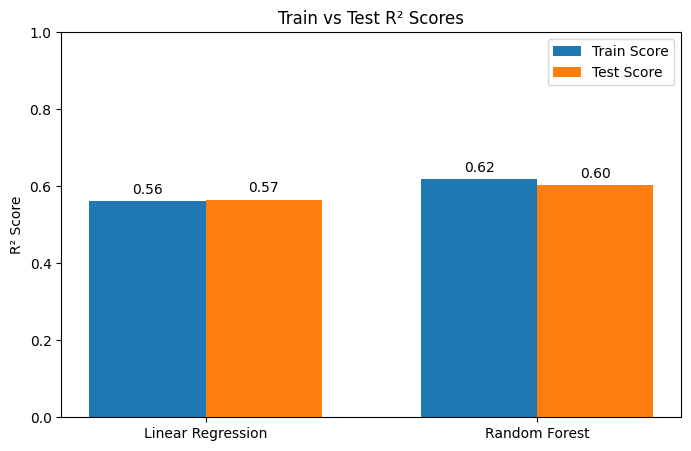

In [ ]:
models = ['Linear Regression', 'Random Forest']

# Preprocess for Random Forest
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

train_scores = [linreg_pipe.score(X_train, y_train), rf.score(X_train_processed, y_train)]
test_scores = [linreg_pipe.score(X_test, y_test), rf.score(X_test_processed, y_test)]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, train_scores, width, label='Train Score')
bars2 = plt.bar(x + width/2, test_scores, width, label='Test Score')

plt.xticks(x, models)
plt.ylabel('R² Score')
plt.title('Train vs Test R² Scores')
plt.legend()
plt.ylim(0, 1)

plt.bar_label(bars1, fmt='%.2f', padding=3)
plt.bar_label(bars2, fmt='%.2f', padding=3);


###**Training vs. Test Performance: Overfitting/Underfitting Check**

The model is **not overfit**.
- Test performance is essentially equal to training performance.
- RMSE is slightly lower on test, R^2 drops slightly
- This means Random Forest generalizes well to unseen data.

- No sign of underfitting either, both models explain similar variance (R^2 ~0.56–0.61), suggesting this is near the practical ceiling for the current features.
- Next step to improve: better/more features rather than a more complex model.

## Model Interpretation & Feature Importance

In [ ]:
# Function to create a color dictionary
def get_color_dict(
    importances,
    color_rest='#006ba4',
    color_top='green',
    top_n=5
):
    # Get the names of the top features
    highlight_feats = (
        importances
        .sort_values(ascending=True)
        .tail(top_n)
        .index
    )

    # Assign green to top features and blue to the remaining features
    colors_dict = {
        col: color_top if col in highlight_feats else color_rest
        for col in importances.index
    }

    return colors_dict

# Function to plot feature importance
def plot_importance_color(
    importances,
    top_n=None,
    figsize=(8, 6),
    color_dict=None
):
    # Sort the importance values
    if top_n is None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    # Plot using the provided colors
    if color_dict is not None:
        colors = plot_vals.index.map(color_dict)

        ax = plot_vals.plot(
            kind='barh',
            figsize=figsize,
            color=colors
        )

    else:
        ax = plot_vals.plot(
            kind='barh',
            figsize=figsize
        )

    # Labels and title
    ax.set(
        xlabel='Importance',
        ylabel='Feature Names',
        title=title
    )

    return ax


In [ ]:

def get_color_dict(
    importances,
    color_rest='#006ba4',
    color_top='green',
    top_n=5
):
    # Get the names of the top features
    highlight_feats = (
        importances
        .sort_values(ascending=True)
        .tail(top_n)
        .index
    )

    # Assign green to top features and blue to the remaining features
    colors_dict = {
        col: color_top if col in highlight_feats else color_rest
        for col in importances.index
    }

    return colors_dict


# Function to plot feature importance (used for Random Forest)
def plot_importance_color(
    importances,
    top_n=None,
    figsize=(8, 6),
    color_dict=None
):
    # Sort the importance values
    if top_n is None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    # Plot using the provided colors
    if color_dict is not None:
        colors = plot_vals.index.map(color_dict)
        ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors)
    else:
        ax = plot_vals.plot(kind='barh', figsize=figsize)

    ax.set(
        xlabel='Importance',
        ylabel='Feature Names',
        title=title
    )

    return ax


# Function to plot coefficients (used for Linear Regression), with optional
# annotations and optional color_dict for highlighting top features
def plot_coeffs(coeffs, top_n=None,  figsize=(4,5), intercept=False,
                annotate=False, ha='left',va='center', size=12, xytext=(4,0),
                  textcoords='offset points', color_dict=None):
    """Plots the top_n coefficients from a Series, with optional annotations."""
    if (intercept==False) & ('intercept' in coeffs.index):
        coeffs = coeffs.drop('intercept')
    if top_n==None:
        ## sort all features and set title
        plot_vals = coeffs#.sort_values()
        title = "All Coefficients - Ranked by Magnitude"
    else:
        ## rank the coeffs and select the top_n
        coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
        top_n_features = coeff_rank.head(top_n)
        plot_vals = coeffs.loc[top_n_features.index].sort_values()
        ## sort features and keep top_n and set title
        title = f"Top {top_n} Largest Coefficients"

    ## build colors from color_dict, if provided
    colors = plot_vals.index.map(color_dict) if color_dict is not None else None

    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors)
    ax.set(xlabel='Coefficient',
           ylabel='Feature Names',
           title=title)
    ax.axvline(0, color='k')

    if annotate==True:
        annotate_hbars(ax, ha=ha,va=va,size=size,xytext=xytext,
                       textcoords=textcoords)
    ## return ax in case want to continue to update/modify figure
    return ax


def annotate_hbars(ax, ha='left',va='center',size=12,  xytext=(4,0),
                  textcoords='offset points'):
    for bar in ax.patches:

        ## calculate center of bar
        bar_ax = bar.get_y() + bar.get_height()/2
        ## get the value to annotate
        val = bar.get_width()
        if val < 0:
            val_pos = 0
        else:
            val_pos = val
        # ha and va stand for the horizontal and vertical alignment
        ax.annotate(f"{val:.3f}", (val_pos,bar_ax), ha=ha,va=va,size=size,
                        xytext=xytext, textcoords=textcoords)

### Linear Regression: Coefficients

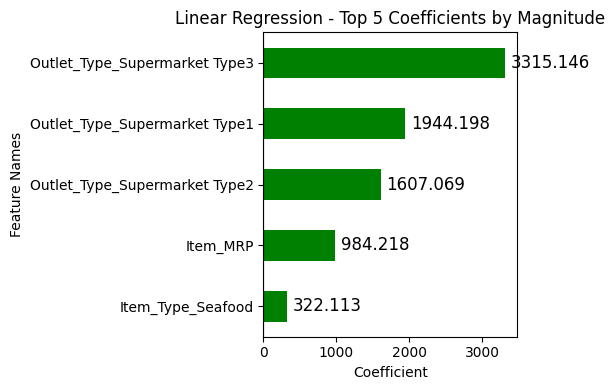

In [ ]:
# Cleaner, README-friendly version: just the top 5 largest coefficients by magnitude
lr_color_dict_top5 = get_color_dict(lr_coefs.abs(), color_rest='#006ba4', color_top='green', top_n=5)
ax = plot_coeffs(lr_coefs, top_n=5, figsize=(6, 4), annotate=True, color_dict=lr_color_dict_top5)
ax.set_title('Linear Regression - Top 5 Coefficients by Magnitude')
plt.tight_layout()
plt.savefig('linear_regression_top5_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


> **Top 3 Most Impactful Features (Linear Regression)**
>
> 1. **`Outlet_Type_Supermarket Type3`** (+3,300) — Selling in a Supermarket Type3 store adds about 3,300 sales units compared to a Grocery Store. Biggest driver by far.
> 2. **`Outlet_Type_Supermarket Type1`** (+1,950) — Supermarket Type1 stores add about 1,950 sales units compared to a Grocery Store.
> 3. **`Outlet_Type_Supermarket Type2`** (+1,600) — Supermarket Type2 stores add about 1,600 sales units compared to a Grocery Store.
>
> **In simple words:** the type of store a product is sold in matters more than anything else in this model — more than price, product type, or fat content. Selling through a supermarket instead of a grocery store is the single best thing for sales.

### Random Forest (Tuned): Feature Importances

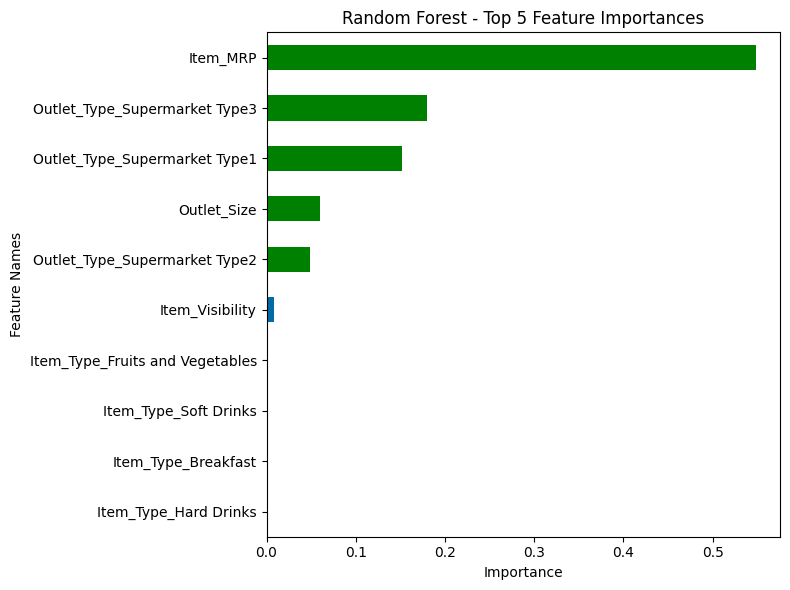

Top 5 most important features (Random Forest):
Item_MRP                         0.547988
Outlet_Type_Supermarket Type3    0.180053
Outlet_Type_Supermarket Type1    0.151290
Outlet_Size                      0.059649
Outlet_Type_Supermarket Type2    0.049270
dtype: float64


In [ ]:
# Extract the fitted preprocessor and the tuned Random Forest model from the pipeline
rf_preprocessor = rf_pipe.named_steps['columntransformer']
rf_model = rf_pipe.named_steps['randomforestregressor']

# Get feature names after preprocessing
rf_feature_names = rf_preprocessor.get_feature_names_out()

# Build a Series of feature importances indexed by feature name
rf_importances = pd.Series(rf_model.feature_importances_, index=rf_feature_names)

# Random Forest importances are already non-negative, so get_color_dict/
# plot_importance_color can be used directly, no absolute value needed
rf_color_dict = get_color_dict(
    rf_importances,
    color_rest='#006ba4',
    color_top='green',
    top_n=5
)

# Plot the top 5 most important features
ax = plot_importance_color(rf_importances, top_n=10, figsize=(8, 6), color_dict=rf_color_dict)
ax.set_title('Random Forest - Top 5 Feature Importances')
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the top 5 most important features
top5 = rf_importances.sort_values(ascending=False).head(5)
print("Top 5 most important features (Random Forest):")
print(top5)


> **Top 5 Most Important Features (Random Forest)**
>
> 1. **`Item_MRP`** (~0.55) — Price is by far the biggest factor. The model relies on this feature more than all others combined.
> 2. **`Outlet_Type_Supermarket Type3`** (~0.18) — Whether a product is sold in a Supermarket Type3 store matters a lot.
> 3. **`Outlet_Type_Supermarket Type1`** (~0.15) — Selling through a Supermarket Type1 store is also a strong signal.
> 4. **`Outlet_Size`** (~0.06) — The size of the store (Small, Medium, High) has a small but real effect.
> 5. **`Outlet_Type_Supermarket Type2`** (~0.05) — Supermarket Type2 stores add a little more predictive power.
>
> **In simple words:** price drives most of the prediction, and store type/size fill in the rest. Everything else — item category, fat content, visibility — barely matters to this model.